In [1]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, top_k_accuracy_score
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize
import pandas as pd
from matplotlib_venn import venn3, venn3_circles
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from itertools import cycle
import unicodedata
import ast, glob, os
from matplotlib import font_manager, rcParams
from matplotlib.lines import Line2D

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

In [2]:
def plot_aligned_calibration_boxplot(df, score_col='Conf1', 
                                   prediction_col='GDD_ENS prediction',
                                   gold_standard_col='Cancer_Type', 
                                   n_bins=10, min_samples=5, model_type=" ", filename=None):
    """
    Plot unified calibration boxplot with properly aligned x-axis scales.
    
    Parameters:
    - df: pandas DataFrame
    - score_col: column with confidence scores
    - prediction_col: column with predicted cancer types
    - gold_standard_col: column with true cancer types
    - n_bins: number of probability bins
    - min_samples: minimum samples required per bin (default: 5)
    """
    # Create a copy to avoid modifying original dataframe
    df_plot = df.copy()
    
    # Add binary correct/incorrect indicator
    df_plot['correct'] = (df_plot[prediction_col] == df_plot[gold_standard_col]).astype(int)
    
    # Create numeric bins first for proper alignment
    df_plot['prob_bin_num'] = pd.cut(df_plot[score_col], bins=n_bins, 
                                    include_lowest=True)
    
    # Get bin midpoints for x-axis positioning
    bin_midpoints = [interval.mid for interval in df_plot['prob_bin_num'].cat.categories]
    bin_width = bin_midpoints[1] - bin_midpoints[0]
    
    # Create labeled bins for display
    df_plot['prob_bin_label'] = pd.cut(df_plot[score_col], bins=n_bins,
                                      labels=[f'{(i/n_bins):.1f}-{((i+1)/n_bins):.1f}' 
                                             for i in range(n_bins)])
    
    # Calculate positive rates (accuracy) within each bin for each cancer type
    bin_stats = df_plot.groupby(['prob_bin_num', gold_standard_col])['correct'].agg(
        ['mean', 'count']).reset_index()
    bin_stats.rename(columns={'mean': 'observed_frac'}, inplace=True)
    
    # Filter out bins with too few samples
    bin_stats = bin_stats[bin_stats['count'] >= min_samples]
    
    # Create the plot
    plt.figure(figsize=(12, 6))
    
    # Prepare data for boxplots - one array per bin
    boxplot_data = []
    positions = []
    valid_bins = []
    
    for i, bin_interval in enumerate(df_plot['prob_bin_num'].cat.categories):
        bin_data = bin_stats[bin_stats['prob_bin_num'] == bin_interval]['observed_frac']
        if len(bin_data) > 0:
            boxplot_data.append(bin_data.values)
            positions.append(bin_midpoints[i])
            valid_bins.append(f'{(bin_interval.left):.1f}-{(bin_interval.right):.1f}')
    
    # Create boxplots at correct x positions
    boxplot = plt.boxplot(boxplot_data, 
                         positions=positions, 
                         widths=bin_width*0.8,  # Make boxes narrower than bin width
                         patch_artist=True)
    
    # Style the boxes and ensure minimum visible width
    for i, box in enumerate(boxplot['boxes']):
        box.set(facecolor='lightblue', alpha=0.7)
        # Get the box vertices
        path = box.get_path()
        vertices = path.vertices
        
        # Calculate the vertical extent of the box (Q1 to Q3)
        y_values = vertices[:, 1]
        q1 = min(y_values)
        q3 = max(y_values)
        box_height = q3 - q1
        
        # If box height is too small, add a minimum height
        min_box_height = 0.02  # Minimum visible height on the plot
        if box_height < min_box_height:
            # Center the minimum box around the median
            median_y = (q1 + q3) / 2
            new_q1 = median_y - min_box_height / 2
            new_q3 = median_y + min_box_height / 2
            
            # Update vertices to new height
            vertices[0, 1] = new_q1  # bottom left
            vertices[1, 1] = new_q1  # bottom right
            vertices[2, 1] = new_q3  # top right
            vertices[3, 1] = new_q3  # top left
            vertices[4, 1] = new_q1  # closing point
    
    # Add overlaying dots for all samples
    for i, (bin_interval, pos) in enumerate(zip([interval for interval in df_plot['prob_bin_num'].cat.categories if len(bin_stats[bin_stats['prob_bin_num'] == interval]['observed_frac']) > 0], positions)):
        bin_data = bin_stats[bin_stats['prob_bin_num'] == bin_interval]['observed_frac'].values
        # Add small random jitter to x position for visibility
        x_jitter = np.random.normal(pos, bin_width*0.05, size=len(bin_data))
        plt.scatter(x_jitter, bin_data, alpha=0.4, s=30, c='darkblue', edgecolors='black', linewidth=0.5, zorder=3)
    
    # Perfect calibration line - now properly aligned
    x_perfect = np.linspace(0, 1, 100)
    plt.plot(x_perfect, x_perfect, 'r--', label='Perfect calibration', linewidth=2)
    
    # Formatting
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.xticks(positions, valid_bins, rotation=45, fontsize=18)
    plt.yticks(fontsize=18)
    plt.xlabel('Predicted probability bin', fontsize=20)
    plt.ylabel('Observed fraction correct', fontsize=20)
    # plt.title(f"{model_type}\n"
    #          'Calibration Boxplot: Distribution of Observed Accuracy\n'
    #          'by Predicted Probability Bin (Across All Cancer Types)')
    plt.legend(loc='upper left', fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if filename != None:
        plt.savefig(filename, dpi=500, bbox_inches='tight')
    plt.show()

def normalize(name):
    # Normalize unicode (e.g., replace en dash/em dash with hyphen)
    name = unicodedata.normalize('NFKD', name)
    name = name.replace('‑', '-')  # non-breaking hyphen
    name = name.replace('‐', '-')  # hyphen
    name = name.replace('–', '-')  # en dash
    name = name.replace('—', '-')  # em dash
    name = name.replace(',', '')  # remove commas
    # name = name.strip().lower()  # lowercase for uniformity
    return name

## Load results

In [4]:
"""Load and prepare the genomic data for analysis."""
# Define paths
gdd_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/GDD-ENS/filtered_batch_msk"
o3_mini_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/gpt-5/filtered_batch_msk"
medgemma_path = "/data1/morrisq/yuj13/llm_genomics/genie_output/qwen3/filtered_batch_msk"

# Load validation set
val_set = pd.read_csv("/data1/morrisq/yuj13/llm_genomics/genie_output/o3-mini/output_nosite_extended_o3-mini.csv")
val_set["SAMPLE_ID"] = "GENIE-MSK-" + val_set["SAMPLE_ID"].astype(str)

# Load clinical data and mapping
data_clinical_sample = pd.read_csv('/data1/morrisq/yuj13/llm_genomics/genie_data_v17.0/data_clinical_sample.txt',sep='\t',comment='#')
mapping_df = pd.read_table("/data1/morrisq/yuj13/llm_genomics/GDD_ENS/data/tumor_type_final.txt")
mapping_df_unique = mapping_df[['CANCER_TYPE', 'Cancer_Type']].drop_duplicates()
mapping = dict(zip(mapping_df_unique['Cancer_Type'], mapping_df_unique['CANCER_TYPE']))

# Load MSK data
# Load MSK data
if len(glob.glob(os.path.join(gdd_path, "*.csv"))) > 0:
    val_cancertypes_gdd_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(gdd_path, "*.csv"))), ignore_index=True)
    val_cancertypes_gdd_msk = val_cancertypes_gdd_msk[val_cancertypes_gdd_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

if len(glob.glob(os.path.join(o3_mini_path, "*.csv"))) > 0:
    val_cancertypes_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(o3_mini_path, "*.csv"))), ignore_index=True)
    val_cancertypes_msk = val_cancertypes_msk[val_cancertypes_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

if len(glob.glob(os.path.join(medgemma_path, "*.csv"))) > 0:
    print(len(glob.glob(os.path.join(medgemma_path, "*.csv"))))
    val_cancertypes_gemma_msk = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(medgemma_path, "*.csv"))), ignore_index=True)
    val_cancertypes_gemma_msk = val_cancertypes_gemma_msk[val_cancertypes_gemma_msk["SAMPLE_ID"].isin(val_set["SAMPLE_ID"])]

# Load non-MSK data
gdd_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/GDD-ENS/filtered_batch_non_msk"
o3_mini_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/gpt-5/filtered_batch_non_msk"
medgemma_path_non_msk = "/data1/morrisq/yuj13/llm_genomics/genie_output/qwen3/filtered_batch_non_msk"

val_cancertypes_gdd = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(gdd_path_non_msk, "*.csv"))), ignore_index=True)
val_cancertypes = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(o3_mini_path_non_msk, "*.csv"))), ignore_index=True)
val_cancertypes_gemma = pd.concat((pd.read_csv(f) for f in glob.glob(os.path.join(medgemma_path_non_msk, "*.csv"))), ignore_index=True)

# Combine MSK and non-MSK data
val_cancertypes_gdd = pd.concat([val_cancertypes_gdd, val_cancertypes_gdd_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")
val_cancertypes = pd.concat([val_cancertypes, val_cancertypes_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")
# val_cancertypes_gemma = pd.concat([val_cancertypes_gemma, val_cancertypes_gemma_msk], ignore_index=True).drop_duplicates(subset="SAMPLE_ID")

# ------Process GDD data with cancer type mapping-------
print("------------------GDD-ENS-------------------")
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Cancer_Type': 'ground_truth'})
ground_truth_cancers = val_cancertypes_gdd.ground_truth.unique()
gdd_pred_cancers = val_cancertypes_gdd.Pred1.unique()

# Merge with clinical data
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    data_clinical_sample[['SAMPLE_ID', 'CANCER_TYPE_DETAILED', 'SEQ_ASSAY_ID']],
    on='SAMPLE_ID',
    how='left'
)

# Map predictions using mapping_df for Pred1
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    mapping_df,
    left_on=['CANCER_TYPE_DETAILED', 'Pred1'],
    right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
    how='left'
)
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'CANCER_TYPE': 'prediction1'})
val_cancertypes_gdd['prediction1'] = (
    val_cancertypes_gdd['prediction1']
    .fillna(val_cancertypes_gdd['Pred1'].map(mapping))
    .fillna('Unknown')
)

# Map predictions using mapping_df for Pred2
val_cancertypes_gdd = val_cancertypes_gdd.merge(
    mapping_df,
    left_on=['CANCER_TYPE_DETAILED', 'Pred2'],
    right_on=['CANCER_TYPE_DETAILED', 'Cancer_Type'],
    how='left'
)
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'CANCER_TYPE': 'prediction2'})
val_cancertypes_gdd['prediction2'] = (
    val_cancertypes_gdd['prediction2']
    .fillna(val_cancertypes_gdd['Pred2'].map(mapping))
    .fillna('Unknown')
)

unknown_rows_gdd = val_cancertypes_gdd[val_cancertypes_gdd['prediction1'] == "UNKNOWN"]
print(f"Number of Unknown rows in GDD predictions: {len(unknown_rows_gdd)}")

val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'prediction1': 'GDD_Prediction1'})
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'prediction2': 'GDD_Prediction2'})
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Conf1': 'GDD_Conf1'})
val_cancertypes_gdd = val_cancertypes_gdd.rename(columns={'Conf2': 'GDD_Conf2'})




print("-------------------------------------------------------------")
# ------Process o3-mini data with cancer type mapping-------
print("------------------O3-mini-------------------")
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].fillna('UNKNOWN')
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].fillna('UNKNOWN')
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].apply(normalize)
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].apply(normalize)

# Fix specific cancer type naming inconsistencies
# Define the values to replace
values_to_replace = {'Indeterminate', 'Not Applicable', 'Unclassifiable', 'Undetermined'}

# Assuming val_cancertypes is your DataFrame
# Replace the specified values with 'UNKNOWN' in prediction1 and prediction2 columns
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].replace(values_to_replace, 'UNKNOWN')
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].replace(values_to_replace, 'UNKNOWN')

val_cancertypes.loc[val_cancertypes['prediction1'] == 'Skin Cancer Non-Melanoma', 'prediction1'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Non-Small-Cell Lung Cancer', 'prediction1'] = 'Non-Small Cell Lung Cancer'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'CNS Cancer (likely meningioma)', 'prediction1'] = 'CNS Cancer'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromat Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromatic Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
val_cancertypes.loc[val_cancertypes['prediction1'] == 'Gastrointestinal Stromenchymal Tumor', 'prediction1'] = 'Gastrointestinal Stromal Tumor'
other_cancers = set(val_cancertypes.prediction1.unique()) - set(val_cancertypes.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in O3-mini prediction1: {other_cancers}")
val_cancertypes['prediction1'] = val_cancertypes['prediction1'].replace(other_cancers, 'OTHERS')

val_cancertypes.loc[val_cancertypes['prediction2'] == 'Skin Cancer Non-Melanoma', 'prediction2'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Non-Small Cell Lung Cancer', 'prediction2'] = 'Non-Small Cell Lung Cancer'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Malignant Mesothelioma', 'prediction2'] = 'Mesothelioma'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Papillary Thyroid Cancer', 'prediction2'] = 'Thyroid Cancer'
val_cancertypes.loc[val_cancertypes['prediction2'] == 'Gastrointestinal Stromen Tumor', 'prediction2'] = 'Gastrointestinal Stromal Tumor'
other_cancers = set(val_cancertypes.prediction2.unique()) - set(val_cancertypes.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in O3-mini prediction2: {other_cancers}")
val_cancertypes['prediction2'] = val_cancertypes['prediction2'].replace(other_cancers, 'OTHERS')

unknown_rows_o3_mini = val_cancertypes[val_cancertypes['prediction1'] == "UNKNOWN"]
others_rows_o3_mini = val_cancertypes[val_cancertypes['prediction1'] == "OTHERS"]
print(f"Number of UNKNOWN rows in O3-mini predictions: {len(unknown_rows_o3_mini)}")
print(f"Number of OTHERS rows in O3-mini predictions: {len(others_rows_o3_mini)}")

val_cancertypes = val_cancertypes.rename(columns={'prediction1': 'o3_mini_Prediction1'})
val_cancertypes = val_cancertypes.rename(columns={'prediction2': 'o3_mini_Prediction2'})
val_cancertypes = val_cancertypes.rename(columns={'prob1': 'o3_mini_Conf1'})
val_cancertypes = val_cancertypes.rename(columns={'prob2': 'o3_mini_Conf2'})


print("-------------------------------------------------------------")

# ------Process medgemma data with cancer type mapping-------
print("------------------MedGemma-------------------")
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].fillna('UNKNOWN')
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].fillna('UNKNOWN')
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].apply(normalize)
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].apply(normalize)

# Fix specific cancer type naming inconsistencies
# Define the values to replace
values_to_replace = {'UNKNOWN', 'Unknown'}

# Assuming val_cancertypes is your DataFrame
# Replace the specified values with 'UNKNOWN' in prediction1 and prediction2 columns
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].replace(values_to_replace, 'UNKNOWN')
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].replace(values_to_replace, 'UNKNOWN')

val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Skin Cancer Non-Melanoma', 'prediction1'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Clear Cell Renal Cell Carcinoma', 'prediction1'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Papillary Cell Renal Cell Carcinoma', 'prediction1'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction1'] == 'Urothelial Cancer (Bladder Cancer)', 'prediction1'] = 'Bladder Cancer'
other_cancers = set(val_cancertypes_gemma.prediction1.unique()) - set(val_cancertypes_gemma.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in MedGemma prediction1: {other_cancers}")
val_cancertypes_gemma['prediction1'] = val_cancertypes_gemma['prediction1'].replace(other_cancers, 'OTHERS')

val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Skin Cancer Non-Melanoma', 'prediction2'] = 'Skin Cancer, Non-Melanoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Clear Cell Renal Cell Carcinoma', 'prediction2'] = 'Renal Cell Carcinoma'
val_cancertypes_gemma.loc[val_cancertypes_gemma['prediction2'] == 'Papillary Cell Renal Cell Carcinoma', 'prediction2'] = 'Renal Cell Carcinoma'
other_cancers = set(val_cancertypes_gemma.prediction2.unique()) - set(val_cancertypes_gemma.ground_truth.unique()) - {'UNKNOWN'}
print(f"Other cancer type in MedGemma prediction2: {other_cancers}")
val_cancertypes_gemma['prediction2'] = val_cancertypes_gemma['prediction2'].replace(other_cancers, 'OTHERS')

unknown_rows_gemma = val_cancertypes_gemma[val_cancertypes_gemma['prediction1'] == "UNKNOWN"]
others_rows_gemma = val_cancertypes_gemma[val_cancertypes_gemma['prediction1'] == "OTHERS"]
print(f"Number of UNKNOWN rows in MedGemma predictions: {len(unknown_rows_gemma)}")
print(f"Number of OTHERS rows in MedGemma predictions: {len(others_rows_gemma)}")

val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prediction1': 'medgemma_Prediction1'})
val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prediction2': 'medgemma_Prediction2'})
val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prob1': 'medgemma_Conf1'})
val_cancertypes_gemma = val_cancertypes_gemma.rename(columns={'prob2': 'medgemma_Conf2'})

print("-------------------------------------------------------------")


1
------------------GDD-ENS-------------------
Number of Unknown rows in GDD predictions: 0
-------------------------------------------------------------
------------------O3-mini-------------------
Other cancer type in O3-mini prediction1: {'Gastrointestinal Stromor Tumor', 'Non-Small Core Lung Cancer', 'Esophagogastrric Cancer', 'Non-Small C Lung Cancer'}
Other cancer type in O3-mini prediction2: {'Gastrointestinal Stromor Tumor'}
Number of UNKNOWN rows in O3-mini predictions: 0
Number of OTHERS rows in O3-mini predictions: 4
-------------------------------------------------------------
------------------MedGemma-------------------
Other cancer type in MedGemma prediction1: {'Lung Adenocarcinoma', 'Diffuse Large B-Cell Lymphoma', 'Meningioma', 'Lynch Syndrome-Associated Cancer', 'Ewing Sarcoma', 'Myeloproliferative Neoplasm', 'NUTM1-rearranged carcinoma', 'Parathyroid Cancer', 'Neurofibromatosis Type 1-Associated Malignant Peripheral Nerve Sheath Tumor', 'Gonadoblastoma', 'Pilocytic 

In [5]:
joint_pred_no_msk = val_cancertypes.merge(
    val_cancertypes_gdd,
    on='SAMPLE_ID',
    how='outer',  # or 'inner' if you want only common samples
    suffixes=('', '_gdd')  # prevent column name clashes
)

joint_pred_no_msk = joint_pred_no_msk.merge(
    val_cancertypes_gemma,
    on='SAMPLE_ID',
    how='outer',  # or 'inner' if you want only common samples
    suffixes=('', '_gemma')
)

/tmp/ipykernel_3466893/1484484983.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', gold_standard_col])['correct'].agg(


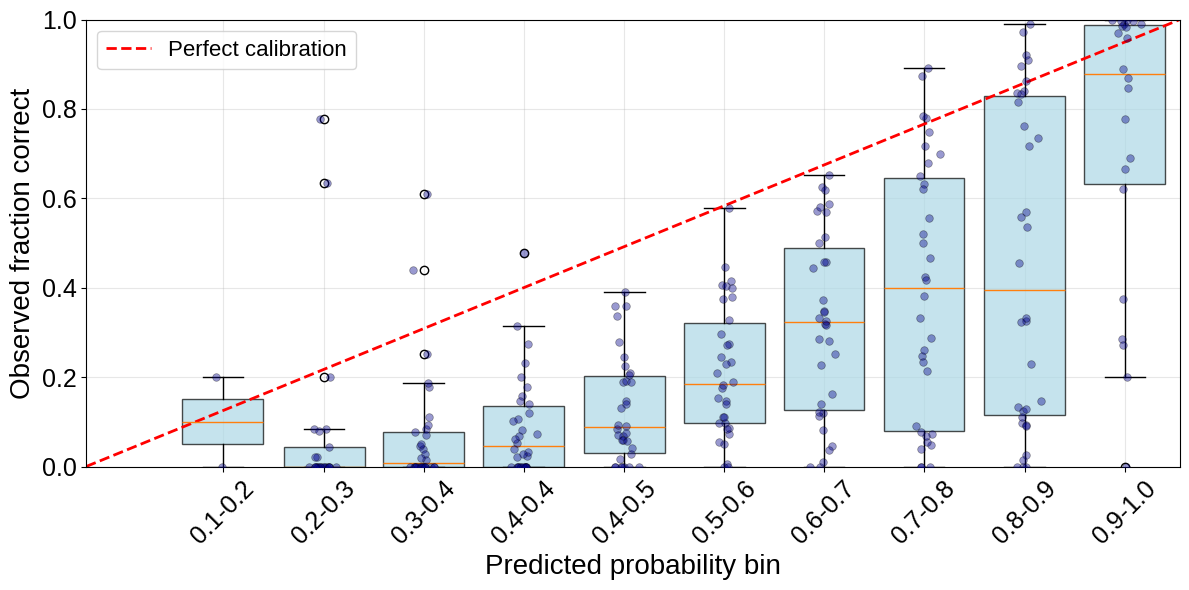

/tmp/ipykernel_3466893/1484484983.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = df_plot.groupby(['prob_bin_num', gold_standard_col])['correct'].agg(


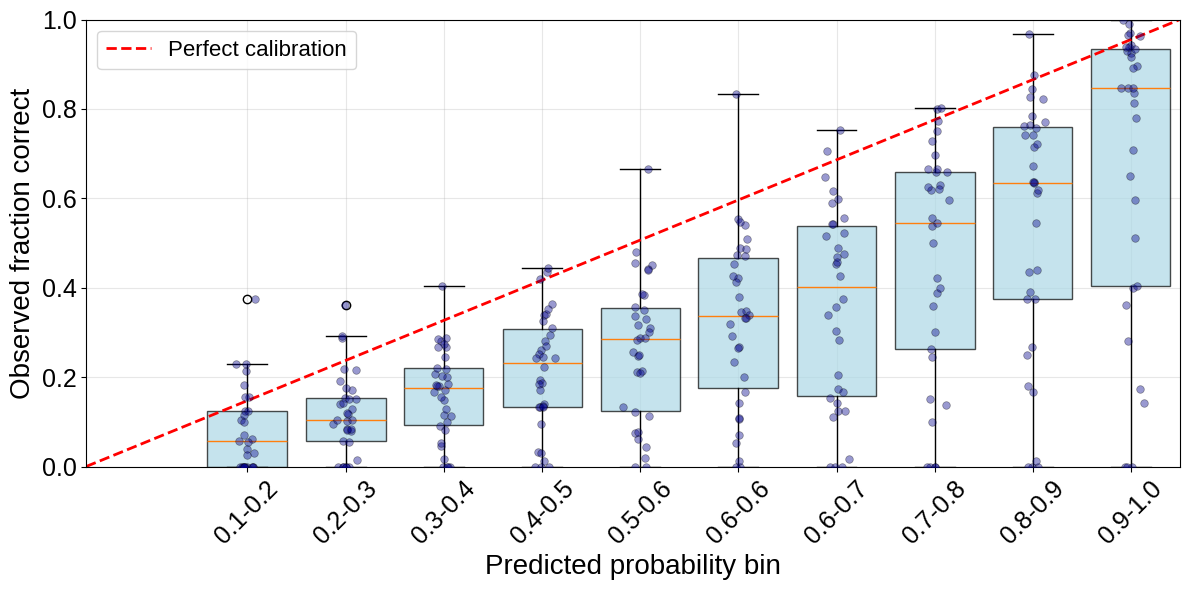

In [6]:
plot_aligned_calibration_boxplot(joint_pred_no_msk,score_col='o3_mini_Conf1',prediction_col='o3_mini_Prediction1',gold_standard_col='ground_truth', model_type="GPT-5", filename = "gpt_5_calibration_curve.pdf")
plot_aligned_calibration_boxplot(joint_pred_no_msk,score_col='GDD_Conf1',prediction_col='GDD_Prediction1',gold_standard_col='ground_truth', model_type="GDD", filename = "gdd_calibration_curve.pdf")
# plot_aligned_calibration_boxplot(joint_pred_no_msk,score_col='medgemma_Conf1',prediction_col='medgemma_Prediction1',gold_standard_col='ground_truth', model_type="MedGemma", filename = "qwen3_calibration_curve.png")
